Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /content/tfds_data/emnist/digits/incomplete.4JK4JP_3.1.0/emnist-test.tfrecord*...:   0%|          | …

Dataset emnist downloaded and prepared to /content/tfds_data/emnist/digits/3.1.0. Subsequent calls will reuse this data.
EMNIST Digits downloaded successfully
train: saved 240000 images
test: saved 40000 images


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

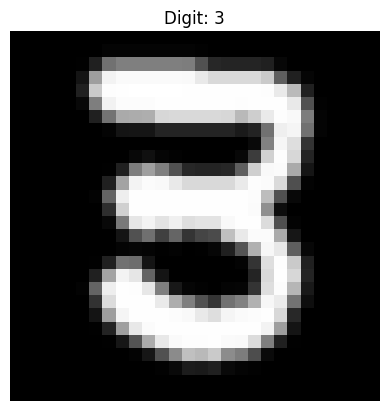

In [1]:
!pip install -q tensorflow tensorflow-datasets pillow

import tensorflow_datasets as tfds
import os
from PIL import Image
import numpy as np
from google.colab import files
import shutil

DATA_DIR = "/content/tfds_data"

(ds_train, ds_test), ds_info = tfds.load(
    "emnist/digits",
    split=["train", "test"],
    as_supervised=True,
    with_info=True,
    data_dir=DATA_DIR
)

print("EMNIST Digits downloaded successfully")

BASE_DIR = "/content/emnist_png"

for split in ["train", "test"]:
    for digit in range(10):
        os.makedirs(f"{BASE_DIR}/{split}/{digit}", exist_ok=True)

def save_png(dataset, split_name, max_images=None):
    counters = {i: 0 for i in range(10)}

    for img, label in tfds.as_numpy(dataset):
        digit = int(label)

        img = img.squeeze()
        img = np.rot90(img, k=1)   # Fix EMNIST orientation
        img = np.flipud(img)


        pil_img = Image.fromarray(img)

        fname = f"{counters[digit]:05d}.png"
        path = f"{BASE_DIR}/{split_name}/{digit}/{fname}"

        pil_img.save(path)
        counters[digit] += 1

        if max_images and sum(counters.values()) >= max_images:
            break

    print(f"{split_name}: saved {sum(counters.values())} images")

save_png(ds_train, "train")
save_png(ds_test, "test")

import matplotlib.pyplot as plt

sample_path = f"{BASE_DIR}/train/3/00010.png"
img = Image.open(sample_path)

plt.imshow(img, cmap="gray")
plt.title("Digit: 3")
plt.axis("off")

ZIP_NAME = "emnist_digits_png"

shutil.make_archive(
    base_name=f"/content/{ZIP_NAME}",
    format="zip",
    root_dir=BASE_DIR
)

files.download(f"/content/{ZIP_NAME}.zip")

